# Notebook 615: He-Burning Crash Debugger

In [1]:
# nb_id is used to identify this notebook's output files (i.e., figures) if there are any
# it should match 
# the first two digits in the notebook's title
nb_id = 615

## Imports

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mesa_reader as mr

import sys
sys.path.append('..')
from src.util import DATA_DIR, MESA_DATA_DIR

plt.style.use('./plotstyle.mplstyle')

## Load core properties and select crashes

In [3]:
df = pd.read_hdf(DATA_DIR / '00_fiducial_core_props_df_v7.h5')

crashes = df[
    (df.is_che == True)
    & (df.is_handled_crash == True)
    & (df.is_He_depleted == False)
].copy()

crashes[['z_key', 'm_zams', 'p_spin_zams', 'case_code']].sort_values(
    ['z_key', 'm_zams', 'p_spin_zams']
)

,z_key,m_zams,p_spin_zams,case_code
5649,0.0200,60.0,1.2,A4
5711,0.0200,70.0,1.2,A4
4909,0.0200,80.0,1.0,A4
4905,0.0200,80.0,1.1,A4
4891,0.0200,80.0,1.2,A4
5545,0.0200,90.0,0.9,A4
5562,0.0200,90.0,1.0,A4
5542,0.0200,90.0,1.1,A4
5541,0.0200,90.0,1.2,A4
5529,0.0200,90.0,1.3,A4


## Build path lookup

In [4]:
PROJECT_BASE = MESA_DATA_DIR / '00_fiducial'

Z_FOLDER_MAP = {
    '0.0200': '0002_ZdivZsun_2d-02',
    '0.0400': '0003_ZdivZsun_4d-02',
    '0.0800': '0004_ZdivZsun_8d-02',
    '0.1000': '0005_ZdivZsun_1d-01',
    '0.2000': '0006_ZdivZsun_2d-01',
    '0.3000': '0007_ZdivZsun_3d-01',
    '0.4000': '0008_ZdivZsun_4d-01',
}

MASSES = [10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100,
          120, 140, 160, 180, 200, 220, 240, 260, 280, 300]
MASS_FOLDER_MAP = {m: f'{i+1:03d}_m{m}' for i, m in enumerate(MASSES)}


def get_run_path(z_key, m_zams, p_spin_zams):
    mass_dir = PROJECT_BASE / Z_FOLDER_MAP[z_key] / MASS_FOLDER_MAP[int(m_zams)]
    for rf in mass_dir.iterdir():
        if not rf.is_dir() or not rf.name.startswith('m'):
            continue
        parts = rf.name.split('_')
        p = float(parts[1].lstrip('p').replace('d', 'e'))
        if abs(p - p_spin_zams) < 0.001:
            return rf
    return None

## Select a model

In [5]:
z_key = '0.0200'
m_zams = 90
p_spin_zams = 1.0

run_path = get_run_path(z_key, m_zams, p_spin_zams)
print(f'Run path: {run_path}')
print(f'LOGS:     {run_path / "LOGS"}')

Run path: /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/013_m90/m9.000d+01_p1.000d+00_w7.272d-05
LOGS:     /mnt/sds-hd/sd23g011/desa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/013_m90/m9.000d+01_p1.000d+00_w7.272d-05/LOGS


## Load history

In [6]:
h = mr.MesaData(str(run_path / 'LOGS/history.data'))
print(f'Model steps: {len(h.model_number)}')

omega_idx = np.where(h.surf_avg_omega > 0)[0]
zams_i = omega_idx[0] if len(omega_idx) > 0 else 0
print(f'ZAMS index:  {zams_i}')
print(f'Final age:   {h.star_age[-1]:.3e} yr')
print(f'center_h1:   {h.center_h1[-1]:.4f}')
print(f'center_he4:  {h.center_he4[-1]:.4f}')
print(f'surface_he4: {h.surface_he4[-1]:.4f}')

Model steps: 10000
ZAMS index:  64
Final age:   3.601e+06 yr
center_h1:   0.0000
center_he4:  0.3131
surface_he4: 0.7427


## HR diagram

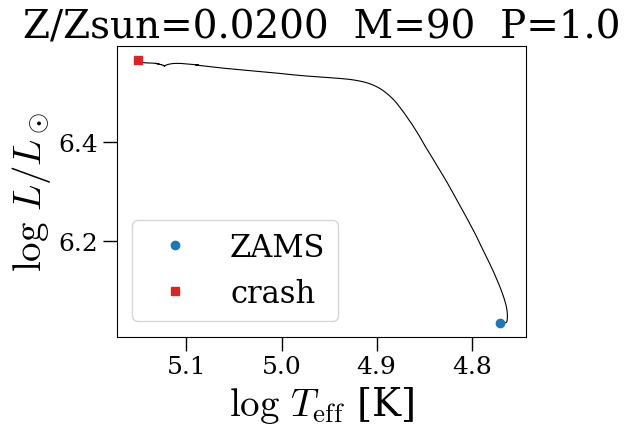

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(h.log_Teff[zams_i:], h.log_L[zams_i:], 'k-', lw=0.8)
ax.plot(h.log_Teff[zams_i], h.log_L[zams_i], 'o', color='C0', ms=6, label='ZAMS')
ax.plot(h.log_Teff[-1], h.log_L[-1], 's', color='C3', ms=6, label='crash')
ax.set_xlabel(r'$\log\,T_{\rm eff}$ [K]')
ax.set_ylabel(r'$\log\,L/L_\odot$')
ax.invert_xaxis()
ax.legend()
ax.set_title(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}')
plt.tight_layout()

## Central abundances

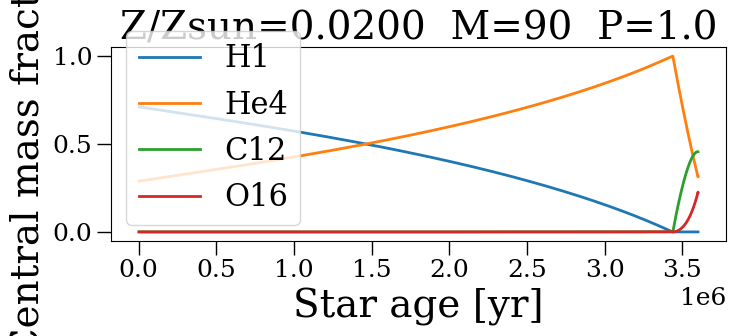

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
age = h.star_age[zams_i:]
ax.plot(age, h.center_h1[zams_i:], label='H1')
ax.plot(age, h.center_he4[zams_i:], label='He4')
ax.plot(age, h.center_c12[zams_i:], label='C12')
ax.plot(age, h.center_o16[zams_i:], label='O16')
ax.set_xlabel('Star age [yr]')
ax.set_ylabel('Central mass fraction')
ax.legend()
ax.set_title(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}')
plt.tight_layout()

## Mass and radius evolution

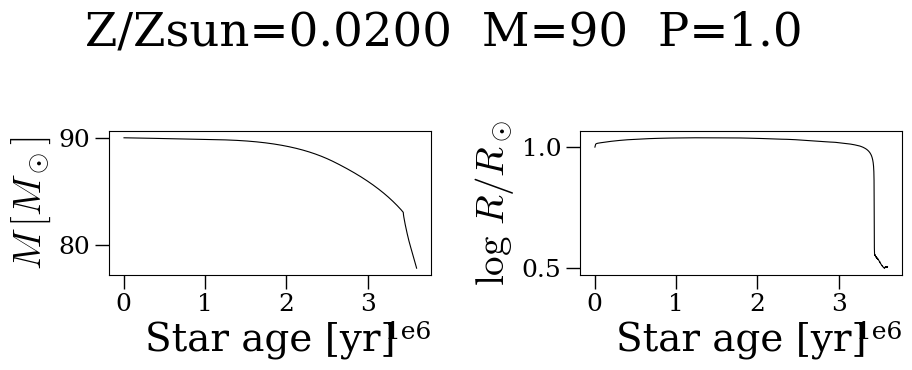

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

age = h.star_age[zams_i:]

axes[0].plot(age, h.star_mass[zams_i:], 'k-', lw=0.8)
axes[0].set_xlabel('Star age [yr]')
axes[0].set_ylabel(r'$M\,[M_\odot]$')

axes[1].plot(age, h.log_R[zams_i:], 'k-', lw=0.8)
axes[1].set_xlabel('Star age [yr]')
axes[1].set_ylabel(r'$\log\,R/R_\odot$')

fig.suptitle(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}')
plt.tight_layout()

## Rotation

/home/hd/hd_hd/hd_lt355/.pyenv/versions/cher/lib/python3.10/site-packages/mesa_reader/__init__.py:373: RuntimeWarning: divide by zero encountered in log10
  return np.log10(self.bulk_data[self._exp10_version(key)])


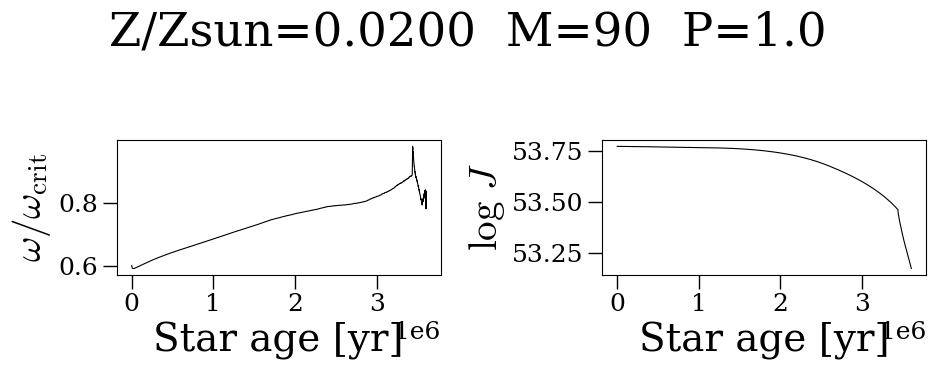

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

age = h.star_age[zams_i:]

axes[0].plot(age, h.surf_avg_omega_div_omega_crit[zams_i:], 'k-', lw=0.8)
axes[0].set_xlabel('Star age [yr]')
axes[0].set_ylabel(r'$\omega/\omega_{\rm crit}$')

axes[1].plot(age, h.log_total_angular_momentum[zams_i:], 'k-', lw=0.8)
axes[1].set_xlabel('Star age [yr]')
axes[1].set_ylabel(r'$\log\,J$')

fig.suptitle(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}')
plt.tight_layout()

## Last profile

In [11]:
logs = mr.MesaLogDir(str(run_path / 'LOGS'))
prof = logs.profile_data()
print(f'Profile model number: {prof.model_number}')
print(f'Number of zones:      {len(prof.zone)}')

Profile model number: 10000
Number of zones:      2089


## Profile structure

In [12]:
prof.bulk_names

('zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'dm',
 'logdq',
 'log_g',
 'radius',
 'velocity',
 'scale_height',
 'pressure_scale_height',
 'dq',
 'energy',
 'entropy',
 'prad',
 'pgas',
 'pgas_div_ptotal',
 'eta',
 'mu',
 'grada',
 'dE_dRho',
 'cp',
 'gamma1',
 'csound',
 'v_div_cs',
 'net_nuclear_energy',
 'net_energy',
 'eps_nuc',
 'non_nuc_neu',
 'pp',
 'cno',
 'tri_alpha',
 'c_alpha',
 'n_alpha',
 'o_alpha',
 'ne_alpha',
 'na_alpha',
 'mg_alpha',
 'si_alpha',
 's_alpha',
 'ar_alpha',
 'ca_alpha',
 'ti_alpha',
 'cr_alpha',
 'fe_co_ni',
 'c12_c12',
 'c12_o16',
 'o16_o16',
 'pnhe4',
 'photo',
 'ni56_co56',
 'co56_fe56',
 'other',
 'abar',
 'zbar',
 'z2bar',
 'ye',
 'neut',
 'h1',
 'h2',
 'he3',
 'he4',
 'li7',
 'be7',
 'be9',
 'be10',
 'b8',
 'c12',
 'c13',
 'n13',
 'n14',
 'n15',
 'o14',
 'o15',
 'o16',
 'o17',
 'o18',
 'f17',
 'f18',
 'f19',
 'ne18',
 'ne19',
 'ne20',
 'ne21',
 'ne22',
 'na21',
 'na2

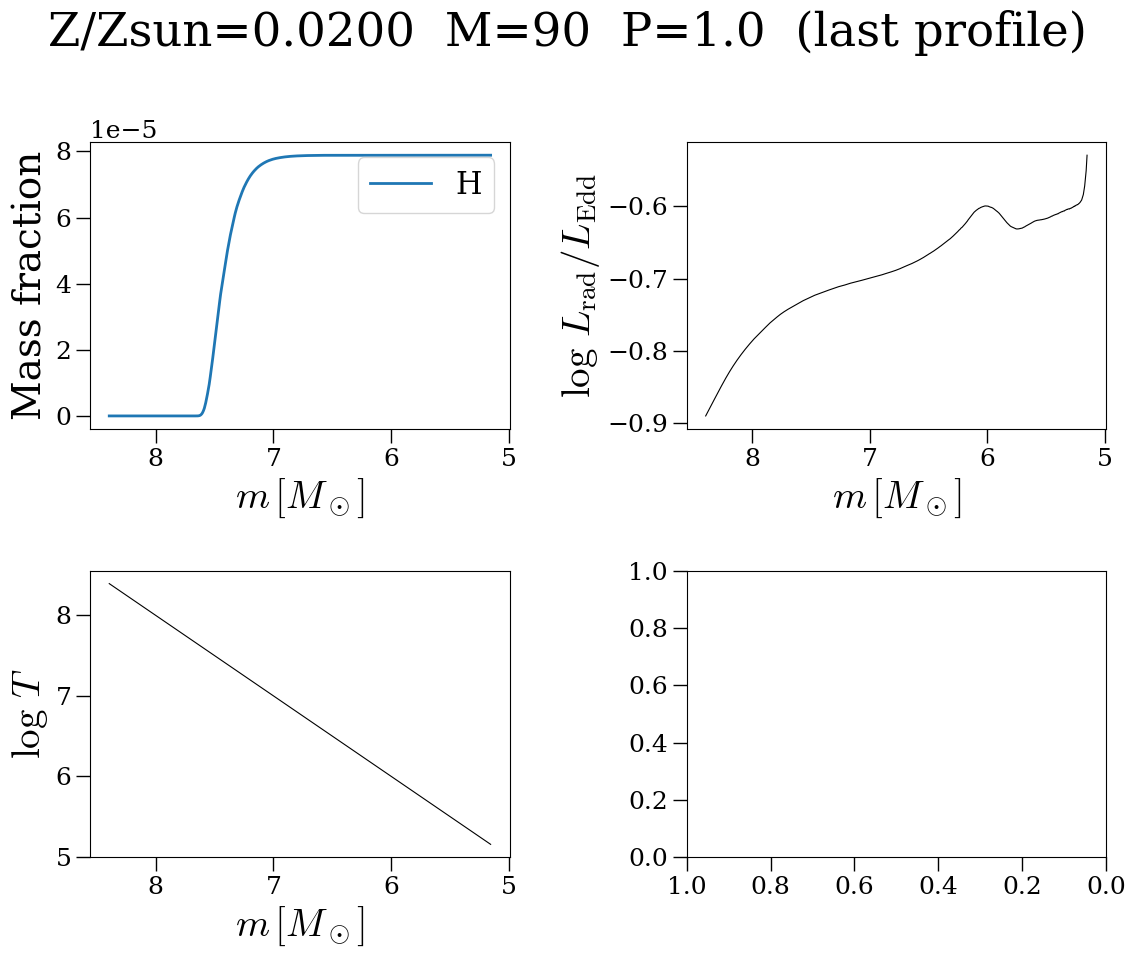

In [13]:
fig, axes = plt.subplots(2,2, figsize=(12, 10))
axes = axes.flatten()

m = prof.logT

axes[0].plot(m, prof.x_mass_fraction_H, label='H')
axes[0].set_xlabel(r'$m\,[M_\odot]$')
axes[0].set_ylabel('Mass fraction')
axes[0].legend()

axes[1].plot(m, prof.log_opacity, 'k-', lw=0.8)
axes[1].set_xlabel(r'$m\,[M_\odot]$')
axes[1].set_ylabel(r'$\log\,L_{\rm rad}/L_{\rm Edd}$')

axes[2].plot(m, prof.logT, 'k-', lw=0.8)
axes[2].set_xlabel(r'$m\,[M_\odot]$')
axes[2].set_ylabel(r'$\log\,T$')


for ax in axes:
    ax.invert_xaxis()
fig.suptitle(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}  (last profile)')
plt.tight_layout()

## pgstar-equivalent plots

### TRho: central track + profile

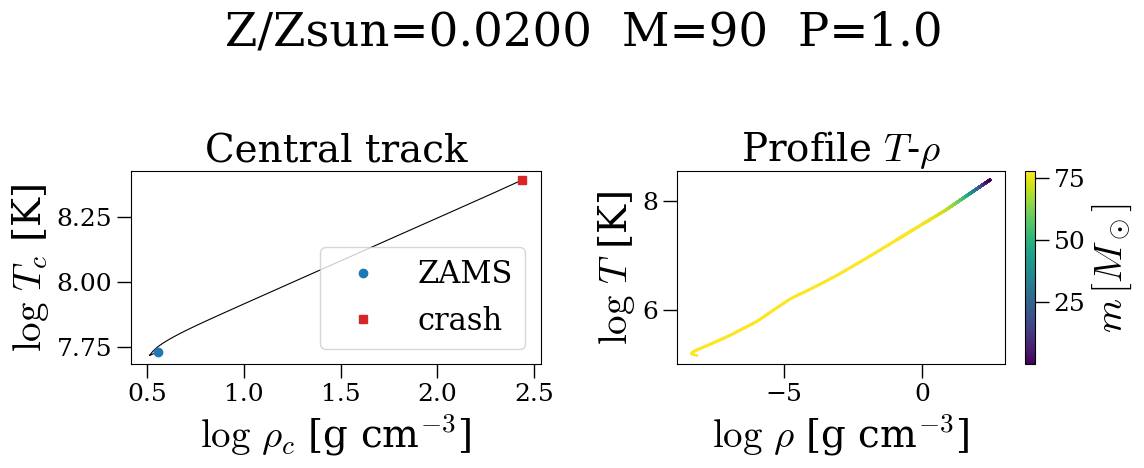

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TRho history (central track)
ax = axes[0]
ax.plot(h.log_center_Rho[zams_i:], h.log_center_T[zams_i:], 'k-', lw=0.8)
ax.plot(h.log_center_Rho[zams_i], h.log_center_T[zams_i], 'o', color='C0', ms=6, label='ZAMS')
ax.plot(h.log_center_Rho[-1], h.log_center_T[-1], 's', color='C3', ms=6, label='crash')
ax.set_xlabel(r'$\log\,\rho_c$ [g cm$^{-3}$]')
ax.set_ylabel(r'$\log\,T_c$ [K]')
ax.legend()
ax.set_title('Central track')

# TRho profile (last profile, colored by mass coordinate)
ax = axes[1]
sc = ax.scatter(prof.logRho, prof.logT, c=prof.mass, s=1, cmap='viridis')
ax.set_xlabel(r'$\log\,\rho$ [g cm$^{-3}$]')
ax.set_ylabel(r'$\log\,T$ [K]')
plt.colorbar(sc, ax=ax, label=r'$m\,[M_\odot]$')
ax.set_title('Profile $T$-$\\rho$')

fig.suptitle(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}')
plt.tight_layout()

### History panels (vs model number)

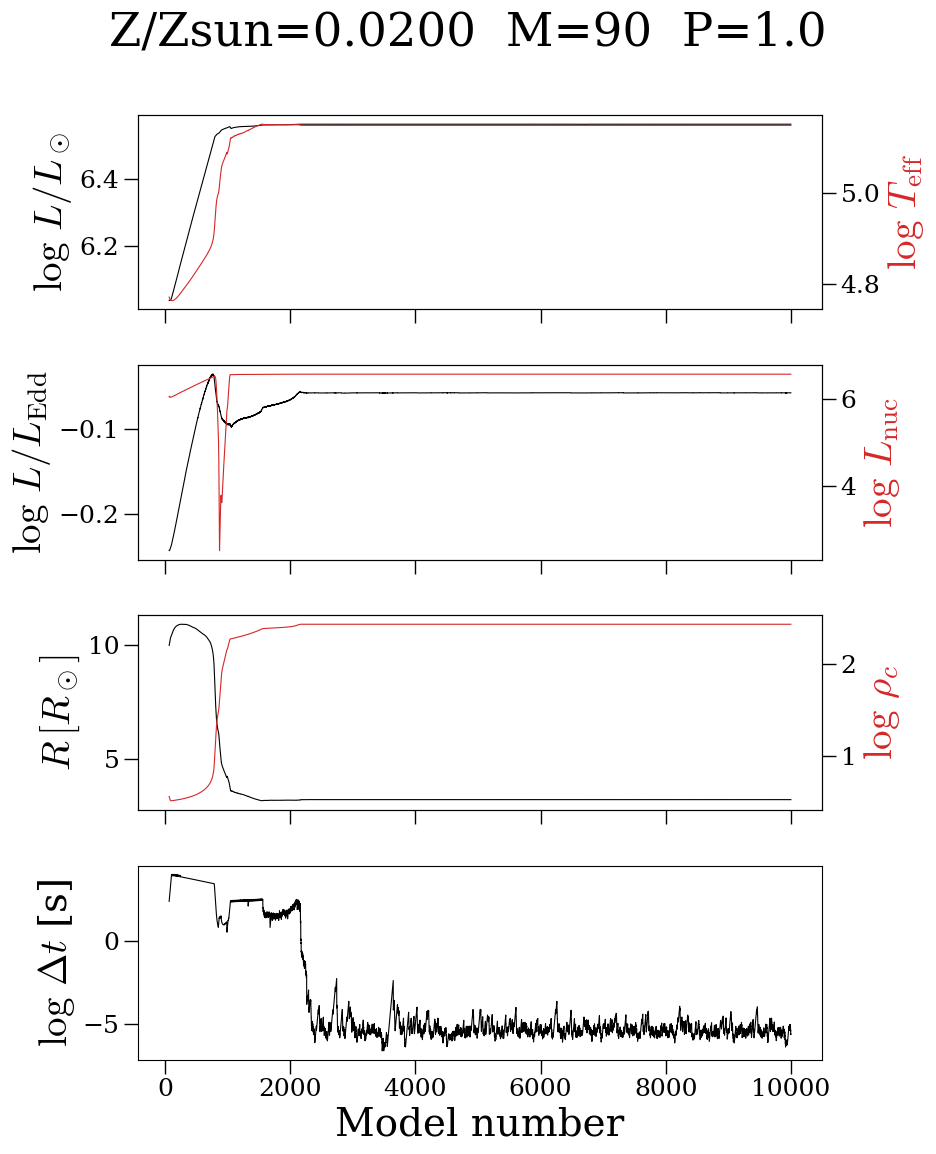

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
mn = h.model_number[zams_i:]

# Panel 1: log_L + log_Teff
ax = axes[0]
ax.plot(mn, h.log_L[zams_i:], 'k-', lw=0.8, label=r'$\log\,L$')
ax.set_ylabel(r'$\log\,L/L_\odot$')
ax2 = ax.twinx()
ax2.plot(mn, h.log_Teff[zams_i:], 'C3-', lw=0.8, label=r'$\log\,T_{\rm eff}$')
ax2.set_ylabel(r'$\log\,T_{\rm eff}$', color='C3')

# Panel 2: log_L_div_Ledd + log_Lnuc
ax = axes[1]
ax.plot(mn, h.log_L_div_Ledd[zams_i:], 'k-', lw=0.8)
ax.set_ylabel(r'$\log\,L/L_{\rm Edd}$')
ax2 = ax.twinx()
ax2.plot(mn, h.log_Lnuc[zams_i:], 'C3-', lw=0.8)
ax2.set_ylabel(r'$\log\,L_{\rm nuc}$', color='C3')

# Panel 3: radius + log_cntr_Rho
ax = axes[2]
ax.plot(mn, h.radius[zams_i:], 'k-', lw=0.8)
ax.set_ylabel(r'$R\,[R_\odot]$')
ax2 = ax.twinx()
ax2.plot(mn, h.log_cntr_Rho[zams_i:], 'C3-', lw=0.8)
ax2.set_ylabel(r'$\log\,\rho_c$', color='C3')

# Panel 4: log_dt
ax = axes[3]
ax.plot(mn, h.log_dt[zams_i:], 'k-', lw=0.8)
ax.set_ylabel(r'$\log\,\Delta t$ [s]')
ax.set_xlabel('Model number')

fig.suptitle(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}')
plt.tight_layout()

### Profile panels 1: thermodynamic structure (vs log tau)

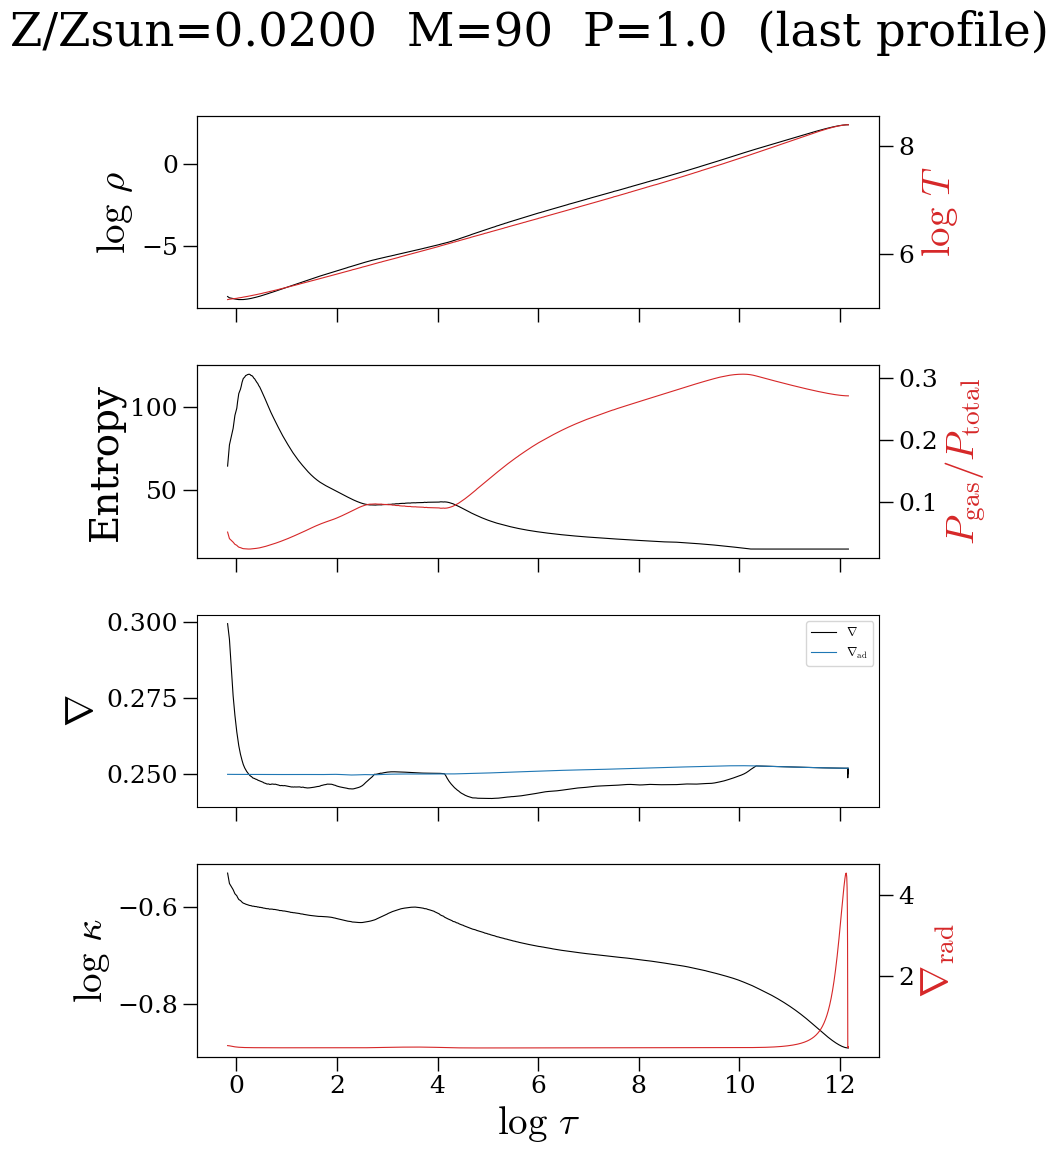

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
logtau = np.log10(prof.tau)

# Panel 1: logRho + logT
ax = axes[0]
ax.plot(logtau, prof.logRho, 'k-', lw=0.8)
ax.set_ylabel(r'$\log\,\rho$')
ax2 = ax.twinx()
ax2.plot(logtau, prof.logT, 'C3-', lw=0.8)
ax2.set_ylabel(r'$\log\,T$', color='C3')

# Panel 2: entropy + pgas/ptotal
ax = axes[1]
ax.plot(logtau, prof.entropy, 'k-', lw=0.8)
ax.set_ylabel(r'Entropy')
ax2 = ax.twinx()
ax2.plot(logtau, prof.pgas_div_ptotal, 'C3-', lw=0.8)
ax2.set_ylabel(r'$P_{\rm gas}/P_{\rm total}$', color='C3')

# Panel 3: gradT + grada
ax = axes[2]
ax.plot(logtau, prof.gradT, 'k-', lw=0.8, label=r'$\nabla$')
ax.plot(logtau, prof.grada, 'C0-', lw=0.8, label=r'$\nabla_{\rm ad}$')
ax.set_ylabel(r'$\nabla$')
ax.legend(fontsize=9)

# Panel 4: log(opacity) + gradr
ax = axes[3]
ax.plot(logtau, np.log10(prof.opacity), 'k-', lw=0.8)
ax.set_ylabel(r'$\log\,\kappa$')
ax2 = ax.twinx()
ax2.plot(logtau, prof.gradr, 'C3-', lw=0.8)
ax2.set_ylabel(r'$\nabla_{\rm rad}$', color='C3')
ax.set_xlabel(r'$\log\,\tau$')

fig.suptitle(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}  (last profile)')
plt.tight_layout()

### Profile panels 3: detailed structure (vs log tau)

/tmp/ipykernel_1711228/3481641130.py:17: RuntimeWarning: divide by zero encountered in log10
  ax.plot(logtau, np.log10(prof.tri_alpha), 'C2-', lw=0.6, label=r'3$\alpha$')
/tmp/ipykernel_1711228/3481641130.py:18: RuntimeWarning: divide by zero encountered in log10
  ax.plot(logtau, np.log10(prof.c_alpha), 'C3-', lw=0.6, label=r'C$\alpha$')


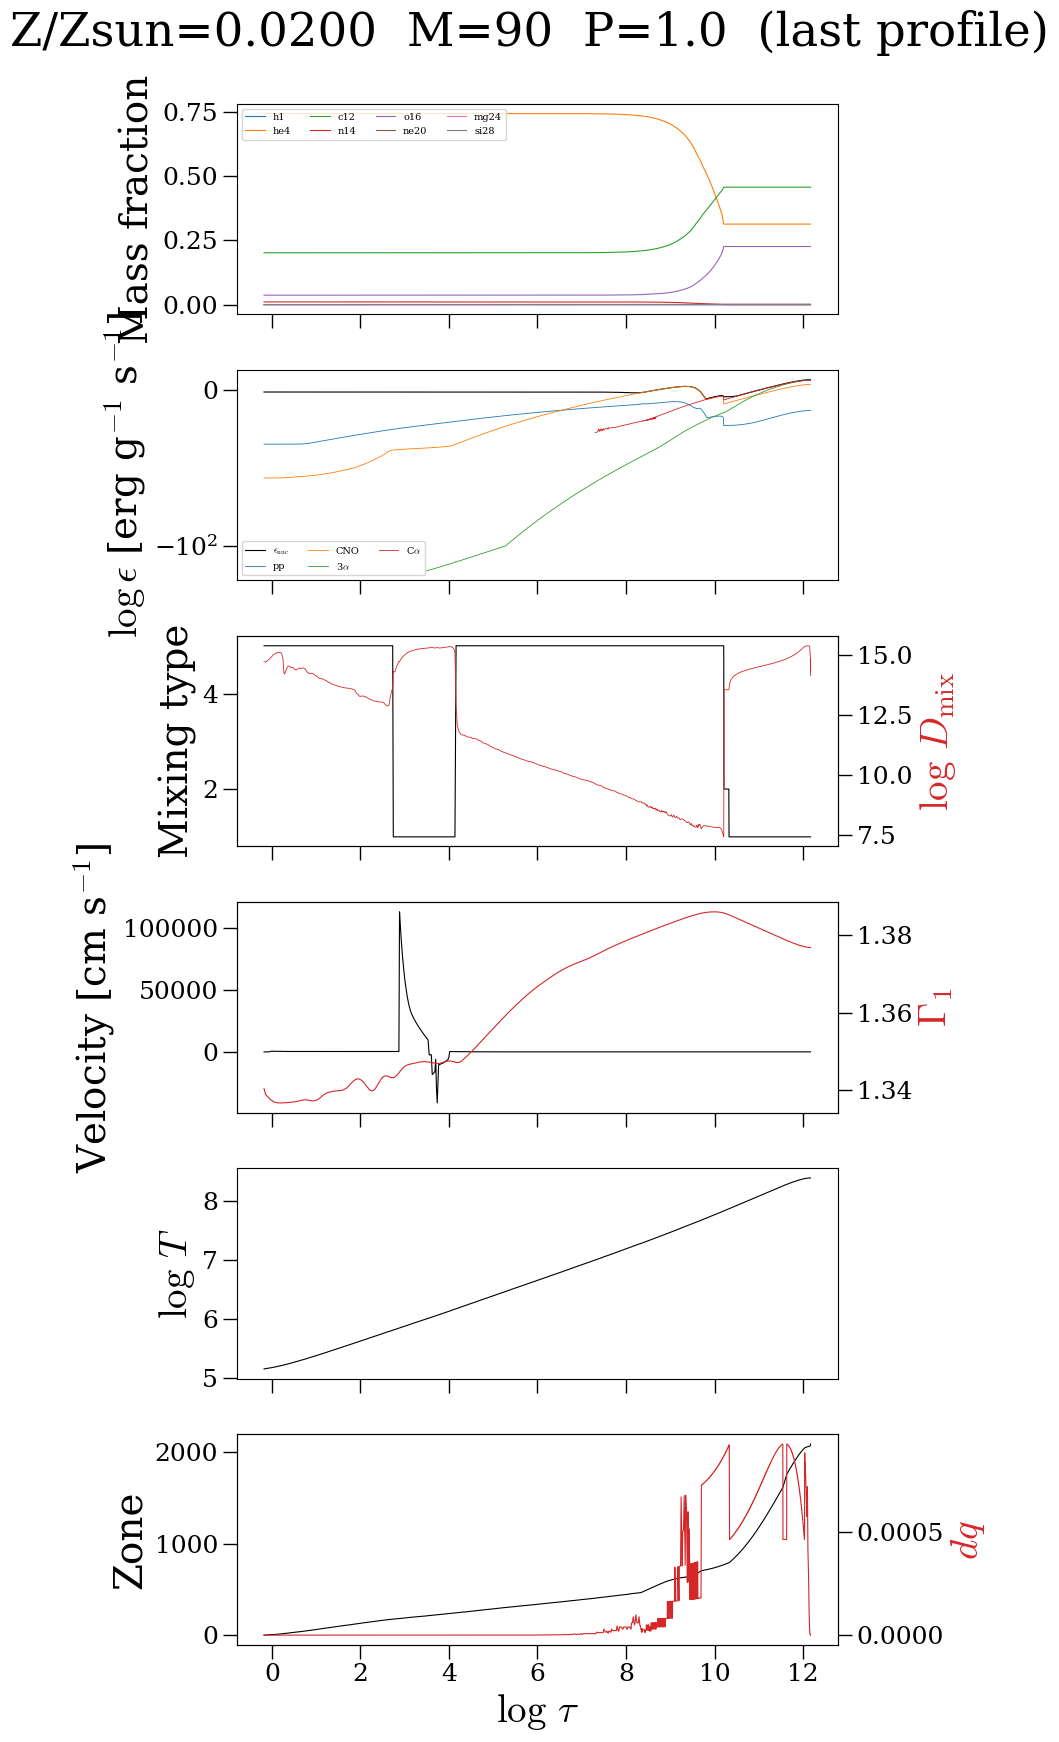

In [19]:
fig, axes = plt.subplots(6, 1, figsize=(10, 18), sharex=True)
logtau = np.log10(prof.tau)

# Panel 1: abundances
ax = axes[0]
for sp, c in [('h1','C0'), ('he4','C1'), ('c12','C2'), ('n14','C3'),
              ('o16','C4'), ('ne20','C5'), ('mg24','C6'), ('si28','C7')]:
    ax.plot(logtau, prof.__getattr__(sp), color=c, lw=0.8, label=sp)
ax.set_ylabel('Mass fraction')
ax.legend(fontsize=7, ncol=4, loc='upper left')

# Panel 2: nuclear energy sources
ax = axes[1]
ax.plot(logtau, np.log10(prof.eps_nuc), 'k-', lw=0.8, label=r'$\epsilon_{\rm nuc}$')
ax.plot(logtau, np.log10(prof.pp), 'C0-', lw=0.6, label='pp')
ax.plot(logtau, np.log10(prof.cno), 'C1-', lw=0.6, label='CNO')
ax.plot(logtau, np.log10(prof.tri_alpha), 'C2-', lw=0.6, label=r'3$\alpha$')
ax.plot(logtau, np.log10(prof.c_alpha), 'C3-', lw=0.6, label=r'C$\alpha$')
ax.set_ylabel(r'$\log\epsilon$ [erg g$^{-1}$ s$^{-1}$]')
ax.set_yscale('symlog', linthresh=1e2)
ax.legend(fontsize=7, ncol=3)

# Panel 3: mixing
ax = axes[2]
ax.plot(logtau, prof.mixing_type, 'k-', lw=0.8, label='mixing type')
ax.set_ylabel('Mixing type')
ax2 = ax.twinx()
ax2.plot(logtau, prof.log_D_mix, 'C3-', lw=0.6, label=r'$\log\,D_{\rm mix}$')
ax2.set_ylabel(r'$\log\,D_{\rm mix}$', color='C3')

# Panel 4: velocity + gamma1
ax = axes[3]
ax.plot(logtau, prof.velocity, 'k-', lw=0.8)
ax.set_ylabel(r'Velocity [cm s$^{-1}$]')
ax2 = ax.twinx()
ax2.plot(logtau, prof.gamma1, 'C3-', lw=0.8)
ax2.set_ylabel(r'$\Gamma_1$', color='C3')

# Panel 5: logT
ax = axes[4]
ax.plot(logtau, prof.logT, 'k-', lw=0.8)
ax.set_ylabel(r'$\log\,T$')

# Panel 6: zone + dq
ax = axes[5]
ax.plot(logtau, prof.zone, 'k-', lw=0.8)
ax.set_ylabel('Zone')
ax2 = ax.twinx()
ax2.plot(logtau, prof.dq, 'C3-', lw=0.8)
ax2.set_ylabel(r'$dq$', color='C3')
ax.set_xlabel(r'$\log\,\tau$')

fig.suptitle(f'Z/Zsun={z_key}  M={int(m_zams)}  P={p_spin_zams}  (last profile)')
plt.tight_layout()